### Minimizing the sum of absolute residuals

Let's test a different loss function. Let's minimize:

$$
    \sum \, | y_{true} - y_{pred}|
$$

In [1]:
import numpy as np
from scipy.optimize import minimize, lsq_linear # 'minimize' for the sum absolute residuals, 'lsq_linear' for the sum of squared residuals
import matplotlib.pyplot as plt
import pandas as pd

### First dataset: head size vs brain weight

In [2]:
dataset = pd.read_csv('headbrain.csv', usecols = lambda column: column not in ('Gender', 'Age Range'))
head = dataset['Head Size(cm^3)'].to_numpy()
brain = dataset['Brain Weight(grams)'].to_numpy()

dataset

,Head Size(cm^3),Brain Weight(grams)
0,4512,1530
1,3738,1297
2,4261,1335
3,3777,1282
4,4177,1590
...,...,...
232,3214,1110
233,3394,1215
234,3233,1104
235,3352,1170


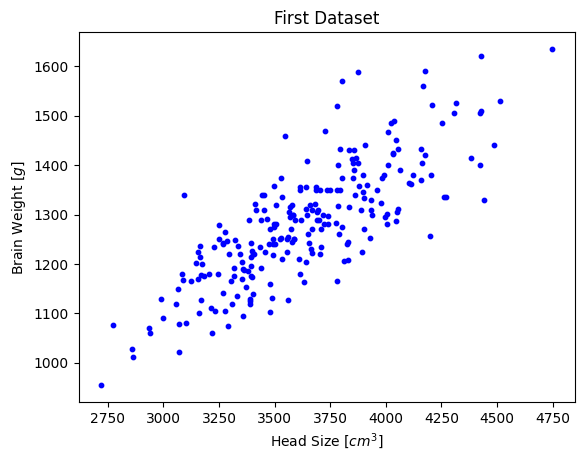

In [3]:
# Plotting first dataset
plt.title('First Dataset')
plt.scatter(head, brain, color = 'blue', s = 10)
plt.xlabel(r'Head Size $[cm^{3}]$')
plt.ylabel(r'Brain Weight $[g]$')
plt.show()

In [4]:
def loss_function(parameters, head, brain): # Loss function: it returns the sum of absolute residuals

    m, q = parameters
    brain_prediction = m * head + q # Straight line
    res = brain - brain_prediction

    return np.sum(np.abs(res))

In [5]:
# Initial values of parameters
m0 = (brain[-1] - brain[0]) / (head[-1] - head[0])
q0 = brain[0] - m0 * head[0]
m0, q0

(np.float64(0.36574487065120426), np.float64(-120.2408563782335))

In [6]:
m, q = minimize( # Best m and q values
    fun = loss_function,
    x0 = (m0, q0),
    args = (head, brain),
    method = 'Nelder-Mead'
).x
m, q

(np.float64(0.26909720433048456), np.float64(303.45493257255055))

Let's compare with OLS fit

In [7]:
design_matrix = np.column_stack((head, np.ones_like(head))) # Design matrix for lsq_linear
m2, q2 = lsq_linear(design_matrix, brain).x
m2, q2

(np.float64(0.26342933948939906), np.float64(325.573421049443))

In [8]:
# Delta (large difference in q)
m - m2, q - q2

(np.float64(0.0056678648410855015), np.float64(-22.11848847689248))

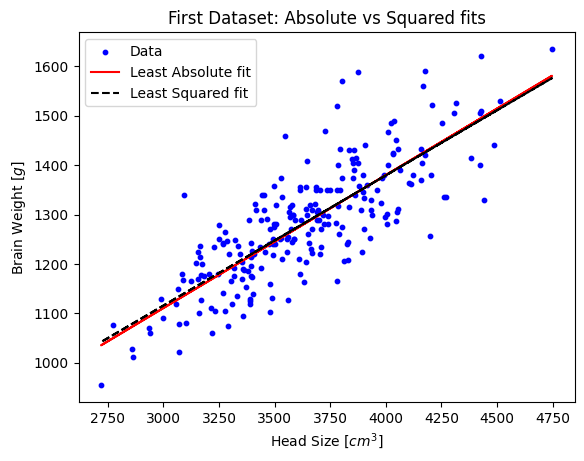

In [9]:
# Plot the best fit lines
brain_pred = m * head + q
brain_pred_2 = m2 * head + q2

plt.title('First Dataset: Absolute vs Squared fits')
plt.scatter(head, brain, color = 'blue', s = 10, label = 'Data')
plt.plot(head, brain_pred, color = 'red', label = 'Least Absolute fit')
plt.plot(head, brain_pred_2, color = 'black', linestyle = 'dashed', label = 'Least Squared fit')
plt.xlabel(r'Head Size $[cm^{3}]$')
plt.ylabel(r'Brain Weight $[g]$')
plt.legend(loc = 'upper left')
plt.show()

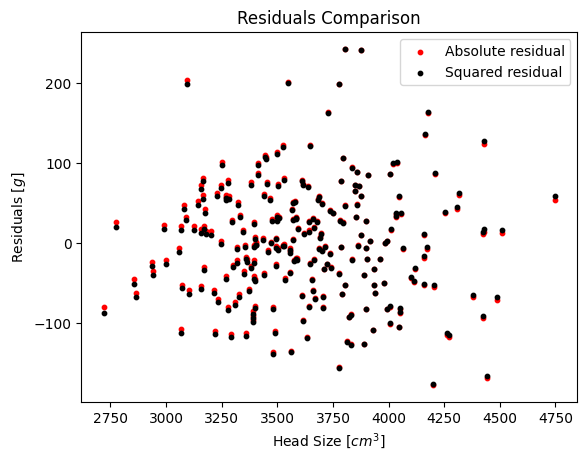

In [10]:
# Compare residuals
plt.title('Residuals Comparison')
plt.scatter(head, brain - brain_pred, color = 'red', s = 10, label = 'Absolute residual')
plt.scatter(head, brain - brain_pred_2, color = 'black', s = 10, label = 'Squared residual')
plt.xlabel(r'Head Size $[cm^{3}]$')
plt.ylabel(r'Residuals $[g]$')
plt.legend(loc = 'best')
plt.show()

### Second dataset: acceleration of a car

In [11]:
# Real dataset here: https://ddl.stanford.edu/content/testing-constant-acceleration
t = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], dtype = np.float32) # s
speed = np.array([2.91, 3.63, 4.59, 5.56, 6.54, 7.53, 8.53, 9.51, 10.48, 11.47, 12.45, 13.43, 14.41, 15.39, 16.4, 17.37, 18.37, 19.35, 20.33, 21.35, 22.35, 23.37, 24.37, 25.33, 26.25], dtype = np.float32) # m/s
acc = np.array([-0.09, 0.76, 1.08, 0.92, 1, 0.92, 1.24, 1.04, 0.79, 1, 1.19, 0.73, 0.9, 0.89, 1.08, 1.46, 1.24, 0.77, 1.08, 0.66, 1.08, 1.26, 0.64, 0.44, 0.95], dtype = np.float32) # m / s^2

x = 0.5 * acc * t ** 2 + speed * t # Target vector. Messy for fun
x

array([  0.      ,   4.01    ,  11.34    ,  20.82    ,  34.16    ,
        49.15    ,  73.5     ,  92.05    , 109.119995, 143.73001 ,
       184.      , 191.89502 , 237.72    , 275.27502 , 335.44    ,
       424.80002 , 452.64    , 440.21503 , 540.9     , 524.78    ,
       663.      , 768.6     , 691.02    , 698.97003 , 903.6     ],
      dtype=float32)

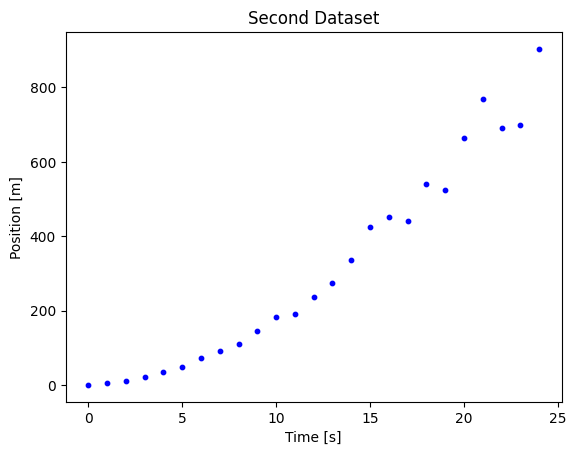

In [12]:
# Plotting second dataset
plt.title('Second Dataset')
plt.scatter(t, x, color = 'blue', s = 10)
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.show()

In [13]:
def loss_function(parameters, t, x): # Rewrite the loss function to handle this new dataset

    a, b, c = parameters
    x_prediction = 0.5 * a * t ** 2 + b * t + c
    res = x - x_prediction

    return np.sum(np.abs(res)).astype(np.float32)

First, let's use OLS method

In [14]:
design_matrix = np.column_stack((t ** 2 / 2, t, np.ones_like(t))) # Design matrix for lsq_linear
a2, b2, c2 = lsq_linear(design_matrix, x).x
a2, b2, c2

(np.float32(2.4115746), np.float32(7.6176333), np.float32(-12.916494))

We can use these values for minimize the sum of absolute residuals

In [15]:
a, b, c = minimize(
    fun = loss_function,
    x0 = (a2, b2, c2), # Initial values: parameters obtained previously
    args = (t, x),
    method = 'Nelder-Mead'
).x
a, b, c

(np.float32(2.8859375), np.float32(3.040029), np.float32(-0.5108778))

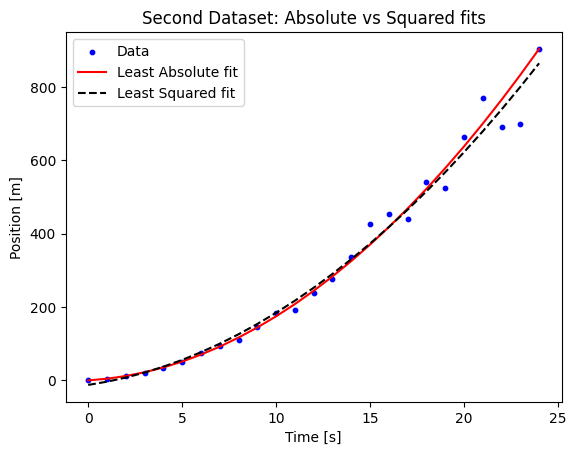

In [16]:
# Plotting results
x_pred = 0.5 * a * t ** 2 + b * t + c
x_pred_2 = 0.5 * a2 * t ** 2 + b2 * t + c2

plt.title('Second Dataset: Absolute vs Squared fits')
plt.scatter(t, x, color = 'blue', s = 10, label = 'Data')
plt.plot(t, x_pred, color = 'red', label = 'Least Absolute fit')
plt.plot(t, x_pred_2, color = 'black', linestyle = 'dashed', label = 'Least Squared fit')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.legend(loc = 'upper left')
plt.show()

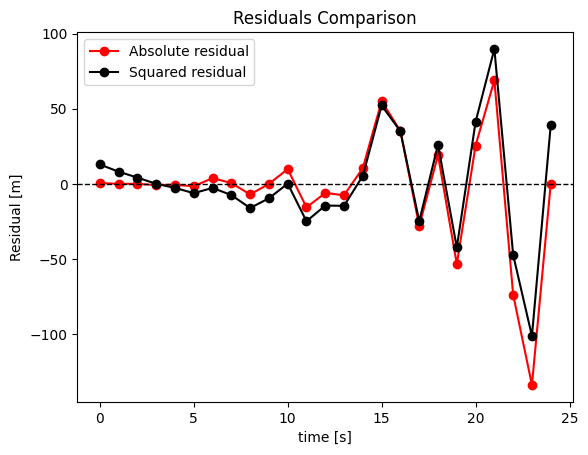

In [17]:
# Residuals plot
plt.title('Residuals Comparison')
plt.plot(t, x - x_pred, marker = 'o', color = 'red', label = 'Absolute residual')
plt.plot(t, x - x_pred_2, marker = 'o', color = 'black', label = 'Squared residual')
plt.axhline(linestyle = '--', color = 'black', linewidth = 1)
plt.xlabel('time [s]')
plt.ylabel('Residual [m]')
plt.legend(loc = 'upper left')
plt.show()